# 🔤 Tokenization: Metinden Sayılara

Bu notebook'ta tokenization'ı derinlemesine inceleyeceğiz:

1. BPE algoritmasını sıfırdan implement edeceğiz
2. SentencePiece ve tiktoken ile karşılaştıracağız
3. Türkçe tokenization zorluklarını analiz edeceğiz

## İçindekiler

1. [Kurulum](#1-kurulum)
2. [Tokenization Temelleri](#2-tokenization-temelleri)
3. [BPE Sıfırdan](#3-bpe-sıfırdan)
4. [SentencePiece ve tiktoken](#4-sentencepiece-ve-tiktoken)
5. [Türkçe Analizi](#5-türkçe-analizi)
6. [Karşılaştırma ve Sonuçlar](#6-karşılaştırma-ve-sonuçlar)

---
## 1. Kurulum

In [15]:
# Gerekli kütüphaneler
# !pip install sentencepiece tiktoken

import re
from typing import List, Dict, Tuple
import matplotlib.pyplot as plt
import numpy as np

print("✅ Temel kütüphaneler yüklendi")

# Opsiyonel kütüphaneler
try:
    import sentencepiece as spm
    HAS_SPM = True
    print("✅ SentencePiece yüklü")
except ImportError:
    HAS_SPM = False
    print("⚠️ SentencePiece yüklü değil (pip install sentencepiece)")

try:
    import tiktoken
    HAS_TIKTOKEN = True
    print("✅ tiktoken yüklü")
except ImportError:
    HAS_TIKTOKEN = False
    print("⚠️ tiktoken yüklü değil (pip install tiktoken)")

✅ Temel kütüphaneler yüklendi
✅ SentencePiece yüklü
✅ tiktoken yüklü


---
## 2. Tokenization Temelleri

Üç temel yaklaşımı karşılaştıralım.

In [16]:
sample_text = "Merhaba dünya! Tokenization öğreniyoruz."

print("📝 Örnek metin:", sample_text)
print("\n" + "="*60)

# Yaklaşım 1: Karakter bazlı
char_tokens = list(sample_text)
print("\n1️⃣ Karakter Bazlı:")
print(f"   Tokenlar: {char_tokens}")
print(f"   Token sayısı: {len(char_tokens)}")

# Yaklaşım 2: Kelime bazlı
word_tokens = re.findall(r"\w+|[^\w\s]", sample_text)
print("\n2️⃣ Kelime Bazlı:")
print(f"   Tokenlar: {word_tokens}")
print(f"   Token sayısı: {len(word_tokens)}")

print("\n3️⃣ Subword (BPE): Aşağıda implement edeceğiz!")

📝 Örnek metin: Merhaba dünya! Tokenization öğreniyoruz.


1️⃣ Karakter Bazlı:
   Tokenlar: ['M', 'e', 'r', 'h', 'a', 'b', 'a', ' ', 'd', 'ü', 'n', 'y', 'a', '!', ' ', 'T', 'o', 'k', 'e', 'n', 'i', 'z', 'a', 't', 'i', 'o', 'n', ' ', 'ö', 'ğ', 'r', 'e', 'n', 'i', 'y', 'o', 'r', 'u', 'z', '.']
   Token sayısı: 40

2️⃣ Kelime Bazlı:
   Tokenlar: ['Merhaba', 'dünya', '!', 'Tokenization', 'öğreniyoruz', '.']
   Token sayısı: 6

3️⃣ Subword (BPE): Aşağıda implement edeceğiz!


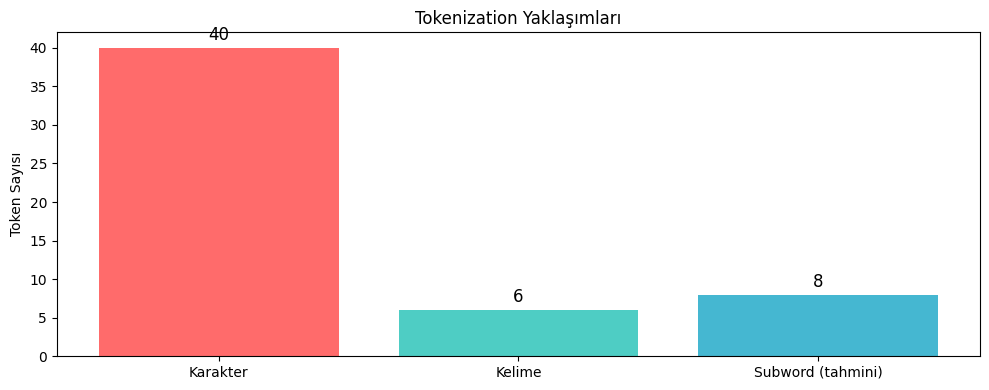

In [17]:
# Karşılaştırma görselleştirmesi
approaches = ['Karakter', 'Kelime', 'Subword (tahmini)']
token_counts = [len(char_tokens), len(word_tokens), 8]

plt.figure(figsize=(10, 4))
bars = plt.bar(approaches, token_counts, color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
plt.ylabel('Token Sayısı')
plt.title(f'Tokenization Yaklaşımları')

for bar, count in zip(bars, token_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(count), ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

---
## 3. BPE Sıfırdan

Byte Pair Encoding algoritmasını sıfırdan implement edelim.

In [18]:
class BPETokenizer:
    """
    Byte Pair Encoding (BPE) Tokenizer - Sıfırdan implementasyon.
    """
    
    def __init__(self):
        self.merges = {}  # (token1, token2) -> new_token_id
        self.vocab = {}   # token_id -> bytes
        
    def _get_pair_counts(self, token_ids: List[int]) -> Dict[Tuple[int, int], int]:
        """Ardışık token çiftlerini say"""
        counts = {}
        for i in range(len(token_ids) - 1):
            pair = (token_ids[i], token_ids[i + 1])
            counts[pair] = counts.get(pair, 0) + 1
        return counts
    
    def _merge_pair(self, token_ids: List[int], pair: Tuple[int, int], new_id: int) -> List[int]:
        """Belirli bir çifti birleştir"""
        new_tokens = []
        i = 0
        while i < len(token_ids):
            if (i < len(token_ids) - 1 and 
                token_ids[i] == pair[0] and 
                token_ids[i + 1] == pair[1]):
                new_tokens.append(new_id)
                i += 2
            else:
                new_tokens.append(token_ids[i])
                i += 1
        return new_tokens
    
    def train(self, text: str, vocab_size: int, verbose: bool = False):
        """
        BPE tokenizer'ı eğit.
        """
        # Başlangıç: UTF-8 byte'ları
        text_bytes = text.encode('utf-8')
        token_ids = list(text_bytes)
        
        # İlk vocab: 256 byte
        self.vocab = {i: bytes([i]) for i in range(256)}
        
        num_merges = vocab_size - 256
        
        if verbose:
            print(f"🚀 BPE Eğitimi Başlıyor")
            print(f"   Hedef vocab: {vocab_size}")
            print(f"   Yapılacak merge: {num_merges}")
            print(f"   Başlangıç token sayısı: {len(token_ids)}\n")
        
        for i in range(num_merges):
            pair_counts = self._get_pair_counts(token_ids)
            
            if not pair_counts:
                break
            
            best_pair = max(pair_counts, key=pair_counts.get)
            best_count = pair_counts[best_pair]
            
            new_id = 256 + i
            token_ids = self._merge_pair(token_ids, best_pair, new_id)
            
            self.merges[best_pair] = new_id
            self.vocab[new_id] = self.vocab[best_pair[0]] + self.vocab[best_pair[1]]
            
            if verbose and (i < 10 or i % 50 == 0):
                token_str = self.vocab[new_id].decode('utf-8', errors='replace')
                print(f"   Merge {i+1}: '{token_str}' (count: {best_count})")
        
        if verbose:
            compression = len(text_bytes) / len(token_ids)
            print(f"\n✅ Eğitim tamamlandı!")
            print(f"   Final vocab: {len(self.vocab)}")
            print(f"   Sıkıştırma: {compression:.2f}x")
        
        return self
    
    def encode(self, text: str) -> List[int]:
        """Metni token ID'lerine dönüştür."""
        token_ids = list(text.encode('utf-8'))
        
        while True:
            pairs = set()
            for i in range(len(token_ids) - 1):
                pair = (token_ids[i], token_ids[i + 1])
                if pair in self.merges:
                    pairs.add(pair)
            
            if not pairs:
                break
            
            best_pair = min(pairs, key=lambda p: self.merges[p])
            new_id = self.merges[best_pair]
            token_ids = self._merge_pair(token_ids, best_pair, new_id)
        
        return token_ids
    
    def decode(self, token_ids: List[int]) -> str:
        """Token ID'lerini metne dönüştür."""
        byte_seq = b''.join(self.vocab[t] for t in token_ids)
        return byte_seq.decode('utf-8', errors='replace')
    
    def tokenize(self, text: str) -> List[str]:
        """Metni token string'lerine dönüştür."""
        token_ids = self.encode(text)
        return [self.vocab[t].decode('utf-8', errors='replace') for t in token_ids]

print("✅ BPETokenizer sınıfı tanımlandı")

✅ BPETokenizer sınıfı tanımlandı


In [19]:
# Eğitim corpus'u: Nasreddin Hoca fıkraları
training_corpus = """
Nasreddin Hoca bir gün eşeğine ters binmiş. Görenler sormuş: "Hoca, neden ters bindin?" 
Hoca cevap vermiş: "Ben ters binmedim, eşek ters duruyor."

Bir gün Nasreddin Hoca göle maya çalıyormuş. Görenler sormuş: "Hoca ne yapıyorsun?" 
Hoca: "Göle maya çalıyorum, belki tutarda yoğurt olur." demiş. 
"Hiç gölden yoğurt olur mu?" demişler. Hoca: "Ya tutarsa?" demiş.

Nasreddin Hoca kaybettiği anahtarı sokak lambasının altında arıyormuş. 
Biri sormuş: "Hoca anahtarı nerede kaybettin?" Hoca: "Evde kaybettim." demiş. 
"Peki neden burada arıyorsun?" diye sorunca Hoca: "Burası daha aydınlık da ondan." demiş.

Hoca bir gün pazara gitmiş. Satıcı sormuş: "Hoca bu kabağı kaça alırsın?" 
Hoca: "Beş akçeye alırım." demiş. Satıcı: "On akçe ister." demiş. 
Hoca düşünmüş ve demiş ki: "Ben beş akçeye almam diyorum, sen on akçeye vermem diyorsun. 
Öyleyse ikimiz de almayalım."

Hoca bir gün ağaca çıkmış. Dalları keserken oturduğu dalı kesmeye başlamış. 
Yoldan geçen biri bağırmış: "Hoca, oturduğun dalı kesme, düşersin!" 
Hoca dinlememiş, dalı kesmeye devam etmiş ve düşmüş.
"""

print(f"📚 Corpus uzunluğu: {len(training_corpus)} karakter")
print(f"📚 Kelime sayısı: {len(training_corpus.split())}")

📚 Corpus uzunluğu: 1070 karakter
📚 Kelime sayısı: 153


In [20]:
# BPE Tokenizer'ı eğit
bpe = BPETokenizer()
bpe.train(training_corpus, vocab_size=350, verbose=True)

🚀 BPE Eğitimi Başlıyor
   Hedef vocab: 350
   Yapılacak merge: 94
   Başlangıç token sayısı: 1169

   Merge 1: 'ş' (count: 32)
   Merge 2: 'ı' (count: 32)
   Merge 3: 'a ' (count: 23)
   Merge 4: ' d' (count: 21)
   Merge 5: 'n ' (count: 19)
   Merge 6: 'Ho' (count: 18)
   Merge 7: 'Hoc' (count: 18)
   Merge 8: 'e ' (count: 14)
   Merge 9: 'mi' (count: 14)
   Merge 10: 'er' (count: 13)
   Merge 51: 'üş' (count: 5)

✅ Eğitim tamamlandı!
   Final vocab: 350
   Sıkıştırma: 2.33x


In [21]:
# Test
test_texts = [
    "Hoca eşeğine binmiş.",
    "Nasreddin Hoca çok akıllıydı.",
    "Göle maya çalıyorum.",
    "Bu bir test cümlesidir.",
]

print("🧪 BPE Tokenization Testleri\n")
print("="*60)

for text in test_texts:
    tokens = bpe.tokenize(text)
    ids = bpe.encode(text)
    decoded = bpe.decode(ids)
    
    print(f"\n📝 Metin: {text}")
    print(f"   Tokenlar: {tokens}")
    print(f"   Token sayısı: {len(tokens)}")
    print(f"   Sıkıştırma: {len(text)/len(tokens):.2f}x")

🧪 BPE Tokenization Testleri


📝 Metin: Hoca eşeğine binmiş.
   Tokenlar: ['Hoca ', 'eş', 'e', 'ğ', 'in', 'e ', 'b', 'in', 'miş', '.']
   Token sayısı: 10
   Sıkıştırma: 2.00x

📝 Metin: Nasreddin Hoca çok akıllıydı.
   Tokenlar: ['Nasreddin ', 'Hoca ', 'ç', 'o', 'k', ' ', 'ak', 'ı', 'l', 'l', 'ı', 'y', 'd', 'ı', '.']
   Token sayısı: 15
   Sıkıştırma: 1.93x

📝 Metin: Göle maya çalıyorum.
   Tokenlar: ['Gö', 'l', 'e ', 'may', 'a ç', 'alı', 'yor', 'u', 'm', '.']
   Token sayısı: 10
   Sıkıştırma: 2.00x

📝 Metin: Bu bir test cümlesidir.
   Tokenlar: ['B', 'u', ' b', 'ir', ' ', 't', 'e', 's', 't', ' ', 'c', 'ü', 'm', 'l', 'e', 's', 'i', 'd', 'ir', '.']
   Token sayısı: 20
   Sıkıştırma: 1.15x


---
## 4. SentencePiece ve tiktoken

Gerçek dünya tokenizer'larıyla karşılaştırma.

In [22]:
# tiktoken (GPT-4)
if HAS_TIKTOKEN:
    enc = tiktoken.get_encoding("cl100k_base")  # GPT-4 encoding
    
    print("🔤 tiktoken (GPT-4) Tokenization\n")
    
    test_sentences = [
        "Hello, world!",
        "Merhaba dünya!",
        "Nasreddin Hoca eşeğine binmiş.",
        "yapamayacaklarımızdanmışçasına",
    ]
    
    for text in test_sentences:
        tokens = enc.encode(text)
        token_strs = [enc.decode([t]) for t in tokens]
        print(f"📝 '{text}'")
        print(f"   Tokenlar: {token_strs}")
        print(f"   Token sayısı: {len(tokens)}")
        print()
else:
    print("⚠️ tiktoken yüklü değil")

🔤 tiktoken (GPT-4) Tokenization

📝 'Hello, world!'
   Tokenlar: ['Hello', ',', ' world', '!']
   Token sayısı: 4

📝 'Merhaba dünya!'
   Tokenlar: ['Mer', 'hab', 'a', ' dü', 'nya', '!']
   Token sayısı: 6

📝 'Nasreddin Hoca eşeğine binmiş.'
   Tokenlar: ['N', 'as', 'redd', 'in', ' H', 'oca', ' e', 'ş', 'e', 'ğ', 'ine', ' bin', 'mi', 'ş', '.']
   Token sayısı: 15

📝 'yapamayacaklarımızdanmışçasına'
   Tokenlar: ['y', 'ap', 'am', 'ay', 'acak', 'lar', 'ım', 'ız', 'dan', 'm', 'ış', 'ças', 'ına']
   Token sayısı: 13



---
## 5. Türkçe Analizi

Türkçe'nin tokenization'daki zorlukları.

In [23]:
# Türkçe vs İngilizce karşılaştırma
comparisons = [
    ("Hello, how are you?", "Merhaba, nasılsın?"),
    ("I am going to the store.", "Ben mağazaya gidiyorum."),
    ("from our houses", "evlerimizden"),
    ("Goodbye", "Görüşürüz"),
    ("as if it were from those that we would not be able to do", 
     "yapamayacaklarımızdanmışçasına"),
]

if HAS_TIKTOKEN:
    print("🇬🇧 vs 🇹🇷 Token Karşılaştırması (GPT-4)\n")
    print("="*70)
    
    en_total = 0
    tr_total = 0
    
    for en_text, tr_text in comparisons:
        en_tokens = len(enc.encode(en_text))
        tr_tokens = len(enc.encode(tr_text))
        
        en_total += en_tokens
        tr_total += tr_tokens
        
        diff = ((tr_tokens - en_tokens) / en_tokens) * 100
        
        print(f"\n🇬🇧 '{en_text}'")
        print(f"   → {en_tokens} token")
        print(f"🇹🇷 '{tr_text}'")
        print(f"   → {tr_tokens} token ({diff:+.0f}%)")
    
    print("\n" + "="*70)
    overhead = ((tr_total - en_total) / en_total) * 100
    print(f"\n📊 Toplam: İngilizce {en_total} token, Türkçe {tr_total} token")
    print(f"   Türkçe overhead: {overhead:+.1f}%")

🇬🇧 vs 🇹🇷 Token Karşılaştırması (GPT-4)


🇬🇧 'Hello, how are you?'
   → 6 token
🇹🇷 'Merhaba, nasılsın?'
   → 9 token (+50%)

🇬🇧 'I am going to the store.'
   → 7 token
🇹🇷 'Ben mağazaya gidiyorum.'
   → 10 token (+43%)

🇬🇧 'from our houses'
   → 3 token
🇹🇷 'evlerimizden'
   → 5 token (+67%)

🇬🇧 'Goodbye'
   → 2 token
🇹🇷 'Görüşürüz'
   → 6 token (+200%)

🇬🇧 'as if it were from those that we would not be able to do'
   → 14 token
🇹🇷 'yapamayacaklarımızdanmışçasına'
   → 13 token (-7%)


📊 Toplam: İngilizce 32 token, Türkçe 43 token
   Türkçe overhead: +34.4%


In [24]:
# Aglütinasyon analizi
agglutinative_examples = [
    "ev",
    "evler",
    "evlerim",
    "evlerimiz",
    "evlerimizde",
    "evlerimizden",
    "evlerimizdeki",
    "evlerimizdekiler",
    "evlerimizdekilere",
    "evlerimizdekilerin",
]

if HAS_TIKTOKEN:
    print("🏠 Aglütinasyon Analizi: 'ev' kelimesi\n")
    
    for word in agglutinative_examples:
        tokens = enc.encode(word)
        token_strs = [enc.decode([t]) for t in tokens]
        print(f"'{word}' ({len(word)} harf) → {len(tokens)} token: {token_strs}")

🏠 Aglütinasyon Analizi: 'ev' kelimesi

'ev' (2 harf) → 1 token: ['ev']
'evler' (5 harf) → 2 token: ['ev', 'ler']
'evlerim' (7 harf) → 3 token: ['ev', 'ler', 'im']
'evlerimiz' (9 harf) → 4 token: ['ev', 'ler', 'im', 'iz']
'evlerimizde' (11 harf) → 5 token: ['ev', 'ler', 'im', 'iz', 'de']
'evlerimizden' (12 harf) → 5 token: ['ev', 'ler', 'im', 'iz', 'den']
'evlerimizdeki' (13 harf) → 6 token: ['ev', 'ler', 'im', 'iz', 'de', 'ki']
'evlerimizdekiler' (16 harf) → 6 token: ['ev', 'ler', 'im', 'iz', 'dek', 'iler']
'evlerimizdekilere' (17 harf) → 7 token: ['ev', 'ler', 'im', 'iz', 'dek', 'il', 'ere']
'evlerimizdekilerin' (18 harf) → 7 token: ['ev', 'ler', 'im', 'iz', 'dek', 'iler', 'in']


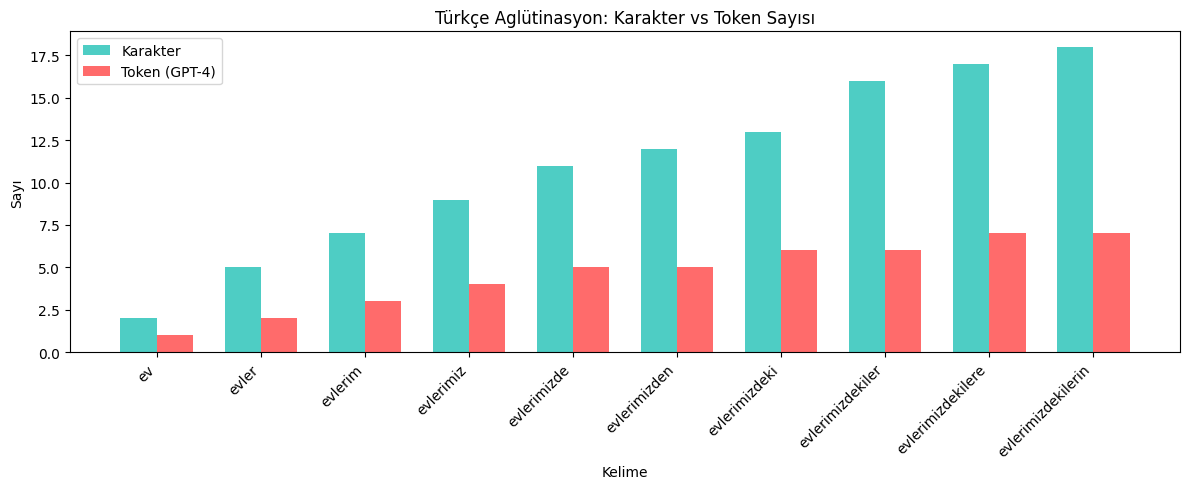

In [25]:
# Görselleştirme
if HAS_TIKTOKEN:
    words = agglutinative_examples
    char_counts = [len(w) for w in words]
    token_counts = [len(enc.encode(w)) for w in words]
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    x = np.arange(len(words))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, char_counts, width, label='Karakter', color='#4ecdc4')
    bars2 = ax.bar(x + width/2, token_counts, width, label='Token (GPT-4)', color='#ff6b6b')
    
    ax.set_xlabel('Kelime')
    ax.set_ylabel('Sayı')
    ax.set_title("Türkçe Aglütinasyon: Karakter vs Token Sayısı")
    ax.set_xticks(x)
    ax.set_xticklabels(words, rotation=45, ha='right')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

---
## 6. Karşılaştırma ve Sonuçlar

In [26]:
# Özet tablo
print("\n" + "="*70)
print("📊 TOKENIZATION ÖZETİ")
print("="*70)

print("""
┌─────────────────┬────────────────┬─────────────────┬──────────────┐
│ Yaklaşım        │ Vocab Boyutu   │ Token/Kelime    │ OOV Problemi │
├─────────────────┼────────────────┼─────────────────┼──────────────┤
│ Karakter        │ ~300           │ Çok fazla       │ Yok          │
│ Kelime          │ 1M+            │ 1               │ Var ❌        │
│ Subword (BPE)   │ 32K-100K       │ 1-3             │ Yok ✅        │
└─────────────────┴────────────────┴─────────────────┴──────────────┘

┌─────────────────┬────────────────┬─────────────────┬──────────────┐
│ Tokenizer       │ Kullanıcı      │ Algoritma       │ Türkçe       │
├─────────────────┼────────────────┼─────────────────┼──────────────┤
│ tiktoken        │ GPT-3/4        │ BPE (byte)      │ Orta         │
│ SentencePiece   │ LLaMA, Mistral │ BPE/Unigram     │ İyi          │
│ HF Tokenizers   │ BERT, etc.     │ Çeşitli         │ Değişir      │
└─────────────────┴────────────────┴─────────────────┴──────────────┘
""")


📊 TOKENIZATION ÖZETİ

┌─────────────────┬────────────────┬─────────────────┬──────────────┐
│ Yaklaşım        │ Vocab Boyutu   │ Token/Kelime    │ OOV Problemi │
├─────────────────┼────────────────┼─────────────────┼──────────────┤
│ Karakter        │ ~300           │ Çok fazla       │ Yok          │
│ Kelime          │ 1M+            │ 1               │ Var ❌        │
│ Subword (BPE)   │ 32K-100K       │ 1-3             │ Yok ✅        │
└─────────────────┴────────────────┴─────────────────┴──────────────┘

┌─────────────────┬────────────────┬─────────────────┬──────────────┐
│ Tokenizer       │ Kullanıcı      │ Algoritma       │ Türkçe       │
├─────────────────┼────────────────┼─────────────────┼──────────────┤
│ tiktoken        │ GPT-3/4        │ BPE (byte)      │ Orta         │
│ SentencePiece   │ LLaMA, Mistral │ BPE/Unigram     │ İyi          │
│ HF Tokenizers   │ BERT, etc.     │ Çeşitli         │ Değişir      │
└─────────────────┴────────────────┴─────────────────┴────────────

In [27]:
# Türkçe için öneriler
print("\n🇹🇷 Türkçe Tokenization İçin Öneriler:\n")

print("""
1. Türkçe-optimized tokenizer kullanın
   - BERTurk, TURNA gibi modellerin tokenizer'ları
   
2. Vocab boyutunu artırın
   - 32K yerine 64K-128K düşünün
   - Daha fazla Türkçe subword öğrenilir
   
3. Türkçe corpus ile eğitin
   - character_coverage=0.9999 kullanın
   - Unigram, aglütinatif diller için daha iyi olabilir
   
4. Token verimliliğini izleyin
   - Aynı anlam için İngilizce'den %30-50 daha fazla token
   - Maliyet ve context açısından önemli
""")


🇹🇷 Türkçe Tokenization İçin Öneriler:


1. Türkçe-optimized tokenizer kullanın
   - BERTurk, TURNA gibi modellerin tokenizer'ları

2. Vocab boyutunu artırın
   - 32K yerine 64K-128K düşünün
   - Daha fazla Türkçe subword öğrenilir

3. Türkçe corpus ile eğitin
   - character_coverage=0.9999 kullanın
   - Unigram, aglütinatif diller için daha iyi olabilir

4. Token verimliliğini izleyin
   - Aynı anlam için İngilizce'den %30-50 daha fazla token
   - Maliyet ve context açısından önemli



---
## 📚 Sonuç

Bu notebook'ta öğrendiklerimiz:

| Kavram | Açıklama |
|--------|----------|
| **Tokenization** | Metin → Token → ID dönüşümü |
| **BPE** | Sık çiftleri birleştiren algoritma |
| **Subword** | Modern LLM'lerin tercihi |
| **Türkçe zorlukları** | Aglütinasyon, veri azlığı |

### Kritik Insight

> Token ≠ Kelime! "ChatGPT" = 3 token, "evlerimizden" = 4+ token
